In [1]:
install.packages("plot3D")
install.packages("scatterplot3d")
install.packages("png")
packages <- c("ggplot2", "dplyr", "patchwork", "plotly", "tidyverse","plot3D", "scatterplot3d","grid", "png")
for (pkg in packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                pkg,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}
source("../../../utils/r_themes.r")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [2]:
umap_file_path <- file.path(
    "../../../data/umap/combined_umap_transformed.parquet"
)
mAP_file_path <- file.path(
    "../../../4.mAP_analysis/data/mAP/mAP_scores_CP_scDINO.parquet"
)
cell_count_file_path <- file.path(
    "../../../2.cell_tracks_data/data/combined_stats.parquet"
)
pca_file_path <- file.path(
    "../../../data/PCA/PCA_2D_combined_features.parquet"
)

# final figure path 
figures_path <- file.path("../figures")
if (!dir.exists(figures_path)) {
    dir.create(figures_path, recursive = TRUE)
}
final_figure_path <- file.path(
    figures_path,
    "metric_v_time_plot.png"
)

umap_df <- arrow::read_parquet(umap_file_path)
mAP_df <- arrow::read_parquet(mAP_file_path)
cell_count_df <- arrow::read_parquet(cell_count_file_path)
pca_df <- arrow::read_parquet(pca_file_path)


In [3]:
umap_df$Metadata_dose <- as.character(umap_df$Metadata_dose)
umap_df$Metadata_dose <- factor(
    umap_df$Metadata_dose, 
    levels = c(
        '0.0',
        '0.61',
        '1.22',
        '2.44',
        '4.88',
        '9.77',
        '19.53',
        '39.06',
        '78.13',
        '156.25'
    )
)

mAP_df$Metadata_dose <- as.character(mAP_df$Metadata_dose)
mAP_df$Metadata_dose <- factor(
    mAP_df$Metadata_dose, 
    levels = c(
        '0.0',
        '0.61',
        '1.22',
        '2.44',
        '4.88',
        '9.77',
        '19.53',
        '39.06',
        '78.13',
        '156.25'
    )
)
cell_count_df$Metadata_dose <- as.character(cell_count_df$Metadata_dose)
cell_count_df$Metadata_dose <- factor(
    cell_count_df$Metadata_dose, 
    levels = c(
        '0',
        '0.61',
        '1.22',
        '2.44',
        '4.88',
        '9.77',
        '19.53',
        '39.06',
        '78.13',
        '156.25'
    )
)
pca_df$Metadata_dose <- as.character(pca_df$Metadata_dose)
pca_df$Metadata_dose <- factor(
    pca_df$Metadata_dose, 
    levels = c(
        '0.0',
        '0.61',
        '1.22', 
        '2.44',
        '4.88',
        '9.77',
        '19.53',
        '39.06',
        '78.13',
        '156.25'
    )
)
umap_df$Metadata_Time <- as.numeric(umap_df$Metadata_Time) * 30
mAP_df$Metadata_Time <- as.numeric(mAP_df$Metadata_Time) * 30
cell_count_df$Metadata_Time <- as.numeric(cell_count_df$Metadata_Time) * 30
pca_df$Metadata_Time <- as.numeric(pca_df$Metadata_Time) * 30


# Plot mAP over time

In [4]:
# replace shuffle values with Shuffled and Not Shuffled
mAP_df$Shuffle <- gsub(
    "True", 
    "Shuffled", 
    mAP_df$Shuffle
)
mAP_df$Shuffle <- gsub(
    "False", 
    "Not Shuffled", 
    mAP_df$Shuffle
)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


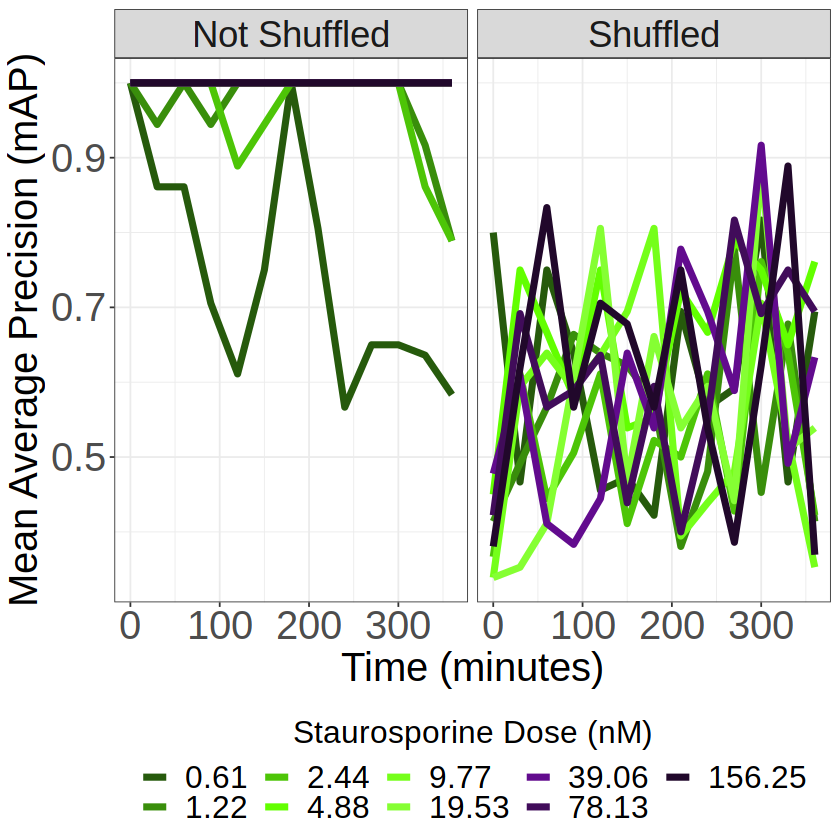

In [5]:
mAP_plot <- (
    ggplot(data = mAP_df, aes(x = Metadata_Time, y = mean_average_precision))
    + geom_line(aes(color = Metadata_dose), size = 2)
    + facet_wrap(Shuffle~.)
    + scale_color_manual(values = color_palette_dose)
    + labs(
        x = "Time (minutes)",
        y = "Mean Average Precision (mAP)",
        color = "Staurosporine Dose (nM)",
    )
    
    # change the legend title
    + guides(
        color = guide_legend(
            override.aes = list(size = 5),
            title.position = "top",
            title.hjust = 0.5,
            title.theme = element_text(size = font_size - 5 ),
            label.theme = element_text(size = font_size - 5),
            nrow = 2,
        ))
    + plot_themes

)
mAP_plot

In [6]:
head(mAP_df)

Metadata_Time,Shuffle,Metadata_dose,Metadata_reference_index,mean_average_precision,indices,p_value,corrected_p_value,below_p,below_corrected_p
<dbl>,<chr>,<fct>,<int>,<dbl>,<list<integer>>,<dbl>,<dbl>,<lgl>,<lgl>
0,Not Shuffled,0.61,-1,1,"0, 9, 18",9.99999e-07,9.99999e-07,TRUE,TRUE
0,Not Shuffled,1.22,-1,1,"1, 10, 19",9.99999e-07,9.99999e-07,TRUE,TRUE
0,Not Shuffled,156.25,-1,1,"8, 17, 26",9.99999e-07,9.99999e-07,TRUE,TRUE
0,Not Shuffled,19.53,-1,1,"5, 14, 23",9.99999e-07,9.99999e-07,TRUE,TRUE
0,Not Shuffled,2.44,-1,1,"2, 11, 20",9.99999e-07,9.99999e-07,TRUE,TRUE
0,Not Shuffled,39.06,-1,1,"6, 15, 24",9.99999e-07,9.99999e-07,TRUE,TRUE


In [7]:
library(scatterplot3d)
library(dplyr)

mAP_df <- mAP_df %>%
  mutate(neg_log10_p = -log10(corrected_p_value)) %>%
  arrange(Shuffle, Metadata_dose, Metadata_Time)

dose_levels <- names(color_palette_dose)
legend_doses <- dose_levels[dose_levels != "0"]

shuffle_lty <- c("Not Shuffled" = 1, "Shuffled" = 3)
shuffle_pch <- c("Not Shuffled" = 19, "Shuffled" = 21)

x_range <- range(mAP_df$Metadata_Time, na.rm = TRUE)
y_range <- c(0, 1)
z_range <- range(mAP_df$neg_log10_p, na.rm = TRUE)

pad <- function(r, frac = 0.05) {
  d <- diff(r)
  c(r[1] - d * frac, r[2] + d * frac)
}
x_range <- pad(x_range)
z_range <- pad(z_range)

map_3d_figure_path <- file.path(figures_path, "mAP_3d_plot.png")
png(map_3d_figure_path, width = 6, height = 6, units = "in", res = 600, bg = "white")
par(mar = c(9, 3.5, 0, 1.5), family = "sans")  # bottom margin increased further, from 7 to 9

s3d <- scatterplot3d(
  x = x_range, y = y_range, z = z_range,
  type = "n",
  angle = 35,
  xlab = "",                      # suppress default — placed manually below
  ylab = "",                      # suppress default — placed manually (mAP)
  zlab = expression(bold(-log[10]~"(corrected p-value)")),   # bolded via expression
  main = "",
  xlim = x_range, ylim = y_range, zlim = z_range,
  y.ticklabs = seq(0, 1, by = 0.2),
  y.margin.add = 0.3,
  scale.y = 0.8,
  box = TRUE,
  grid = TRUE,
  lty.grid = "dashed",
  col.grid = "grey85",
  color = "grey40",
  cex.lab = 1.1,
  cex.axis = 0.9,
  font.lab = 2,
  pch = ""
)

# --- manually place "Time" label along the x-axis direction ---
x_axis_end_coords <- s3d$xyz.convert(x = x_range[2], y = y_range[1], z = z_range[1])
x_axis_start_coords <- s3d$xyz.convert(x = x_range[1], y = y_range[1], z = z_range[1])

x_dx <- x_axis_end_coords$x - x_axis_start_coords$x
x_dy <- x_axis_end_coords$y - x_axis_start_coords$y
time_axis_angle <- atan2(x_dy, x_dx) * 180 / pi

time_label_pos <- s3d$xyz.convert(
  x = mean(x_range),
  y = y_range[1],
  z = -2
)

text(
  x = time_label_pos$x, y = time_label_pos$y,
  labels = "Time (minutes)",
  srt = time_axis_angle,
  font = 2,
  cex = 1.1,
  xpd = NA
)

# --- manually place "mAP" label along the depth (y) axis direction ---
axis_end_coords <- s3d$xyz.convert(x = x_range[1], y = y_range[2], z = z_range[1])
axis_start_coords <- s3d$xyz.convert(x = x_range[1], y = y_range[1], z = z_range[1])

dx <- axis_end_coords$x - axis_start_coords$x
dy <- axis_end_coords$y - axis_start_coords$y
axis_angle <- atan2(dy, dx) * 180 / pi

mAP_label_pos <- s3d$xyz.convert(x = 550, y = 0.2, z = -1)

text(
  x = mAP_label_pos$x, y = mAP_label_pos$y,
  labels = "mAP",
  srt = axis_angle,
  font = 2,
  cex = 1.1,
  xpd = NA
)

for (s in names(shuffle_lty)) {
  d_all <- subset(mAP_df, Shuffle == s)

  for (dose in dose_levels) {
    d_dose <- subset(d_all, Metadata_dose == dose)
    if (nrow(d_dose) == 0) next
    d_dose <- d_dose[order(d_dose$Metadata_Time), ]

    this_col <- unname(color_palette_dose[as.character(dose)])
    coords <- s3d$xyz.convert(d_dose$Metadata_Time, d_dose$mean_average_precision, d_dose$neg_log10_p)

    floor_coords <- s3d$xyz.convert(d_dose$Metadata_Time, d_dose$mean_average_precision, rep(z_range[1], nrow(d_dose)))
    segments(coords$x, coords$y, floor_coords$x, floor_coords$y,
             col = adjustcolor(this_col, alpha.f = 0.15), lwd = 1)

    lines(coords$x, coords$y, col = this_col, lwd = 2.5, lty = shuffle_lty[s])
    points(coords$x, coords$y,
           bg = if (shuffle_pch[s] == 21) this_col else NA,
           col = if (shuffle_pch[s] == 21) "black" else this_col,
           pch = shuffle_pch[s], cex = 1.3, lwd = 1.2)
  }
}

# --- overlay legends directly on this same panel, right at the bottom ---
# switch to normalized (0-1) device coordinates for this panel so we can
# place things by fraction of the panel rather than data units
op <- par(usr = c(0, 1, 0, 1), xpd = NA)

legend(
  x = 0.00, y = -0.10,     # negative y = below the plot box, in the margin
  legend = legend_doses,
  col = unname(color_palette_dose[legend_doses]),
  pch = 19,
  lwd = 2.5,
  title = "Dose (nM)",
  title.font = 2,
  bty = "n",
  cex = 0.8,
  ncol = ceiling(length(legend_doses) / 2),
  x.intersp = 0.4,
  y.intersp = 0.7,
  text.width = NA,
  xjust = 0
)

legend(
  x = 0.80, y = -0.09,     # negative y = below the plot box, in the margin
  legend = names(shuffle_lty),
  lty = shuffle_lty,
  pch = c(19, 21),
  pt.bg = c(NA, "grey60"),
  col = "black",
  lwd = 2.5,
  title = "Shuffle",
  title.font = 2,
  bty = "n",
  cex = 0.8,
  y.intersp = 0.9,
  xjust = 0
)

par(op)
dev.off()
trim_white_border <- function(path, threshold = 0.999, pad_px = 20) {
  img <- readPNG(path)

  if (dim(img)[3] >= 3) {
    is_white <- (img[,,1] > threshold) & (img[,,2] > threshold) & (img[,,3] > threshold)
  } else {
    is_white <- img[,,1] > threshold
  }

  row_has_content <- which(rowSums(!is_white) > 0)
  col_has_content <- which(colSums(!is_white) > 0)

  row_range <- range(row_has_content)
  col_range <- range(col_has_content)

  row_start <- max(1, row_range[1] - pad_px)
  row_end   <- min(dim(img)[1], row_range[2] + pad_px)
  col_start <- max(1, col_range[1] - pad_px)
  col_end   <- min(dim(img)[2], col_range[2] + pad_px)

  cropped <- img[row_start:row_end, col_start:col_end, ]
  writePNG(cropped, path)
}

trim_white_border(map_3d_figure_path)

pdf 
  2

In [8]:
umap_df$Metadata_dose_w_unit <- paste0(
    umap_df$Metadata_dose, 
    " nM"
)
umap_df$Metadata_dose_w_unit <- as.character(umap_df$Metadata_dose_w_unit)
umap_df$Metadata_dose_w_unit <- factor(
    umap_df$Metadata_dose_w_unit, 
    levels = c(
        '0.0 nM',
        '0.61 nM',
        '1.22 nM',
        '2.44 nM',
        '4.88 nM',
        '9.77 nM',
        '19.53 nM',
        '39.06 nM',
        '78.13 nM',
        '156.25 nM'
    )
)

## plot umap over time

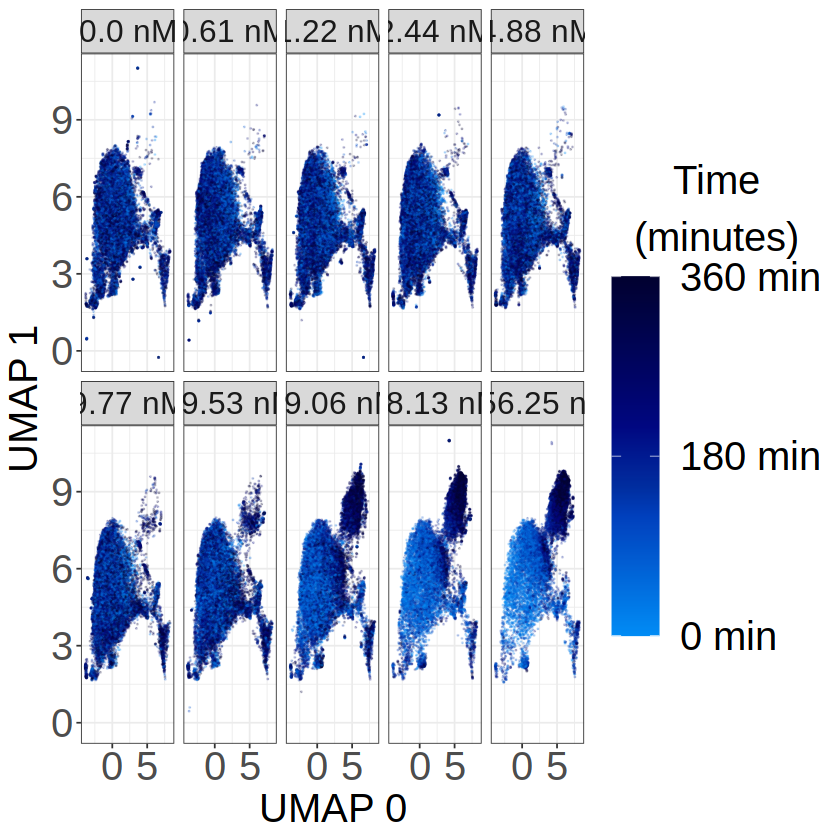

In [9]:
umap_df$Metadata_Time <- as.numeric(umap_df$Metadata_Time)
umap_plot_facet <- (
    ggplot(data = umap_df, aes(x = UMAP0, y = UMAP1))
    + geom_point(aes(color = Metadata_Time), size = 0.2, alpha = 0.2)
    + scale_color_gradientn(
        colors = temporal_palette,
        breaks = c(0, 180, 360), # breaks at 0, 90, and 360 minutes
        labels = c("0 min", "180 min", "360 min")
    )
    + labs(
        x = "UMAP 0",
        y = "UMAP 1",
        color = "Time\n(minutes)",
    )
    + facet_wrap(Metadata_dose_w_unit~., nrow = 2)
    + guides(
        color = guide_colorbar(
            title.position = "top",
            title.hjust = 0.5,
            title.theme = element_text(size = 24),
            # make the legend longer 
            barwidth = 2,
            # make the color bar on vertical
            barheight = 15,
        ))
    + plot_themes
    # override the facet strip text size
    + theme(
        strip.text = element_text(size = font_size - 5),
        legend.position = "right",
    )
)
umap_plot_facet

In [10]:

# calculate the centroid of each UMAP cluster dose and time wise
umap_df_centroids <- umap_df %>% group_by(Metadata_dose, Metadata_Time) %>% summarise(
    UMAP0_centroid = mean(UMAP0),
    UMAP1_centroid = mean(UMAP1)
)
umap_df_centroids$Metadata_Time <- as.numeric(gsub(" min", "", umap_df_centroids$Metadata_Time))
umap_df_centroids$Metadata_dose_w_unit <- paste0(
    umap_df_centroids$Metadata_dose, 
    " nM"
)
umap_df_centroids$Metadata_dose_w_unit <- as.character(umap_df_centroids$Metadata_dose_w_unit)
umap_df_centroids$Metadata_dose_w_unit <- factor(
    umap_df_centroids$Metadata_dose_w_unit, 
    levels = c(
        '0.0 nM',
        '0.61 nM',
        '1.22 nM',
        '2.44 nM',
        '4.88 nM',
        '9.77 nM',
        '19.53 nM',
        '39.06 nM',
        '78.13 nM',
        '156.25 nM'
    )
)

`summarise()` has grouped output by 'Metadata_dose'. You can override using the
`.groups` argument.


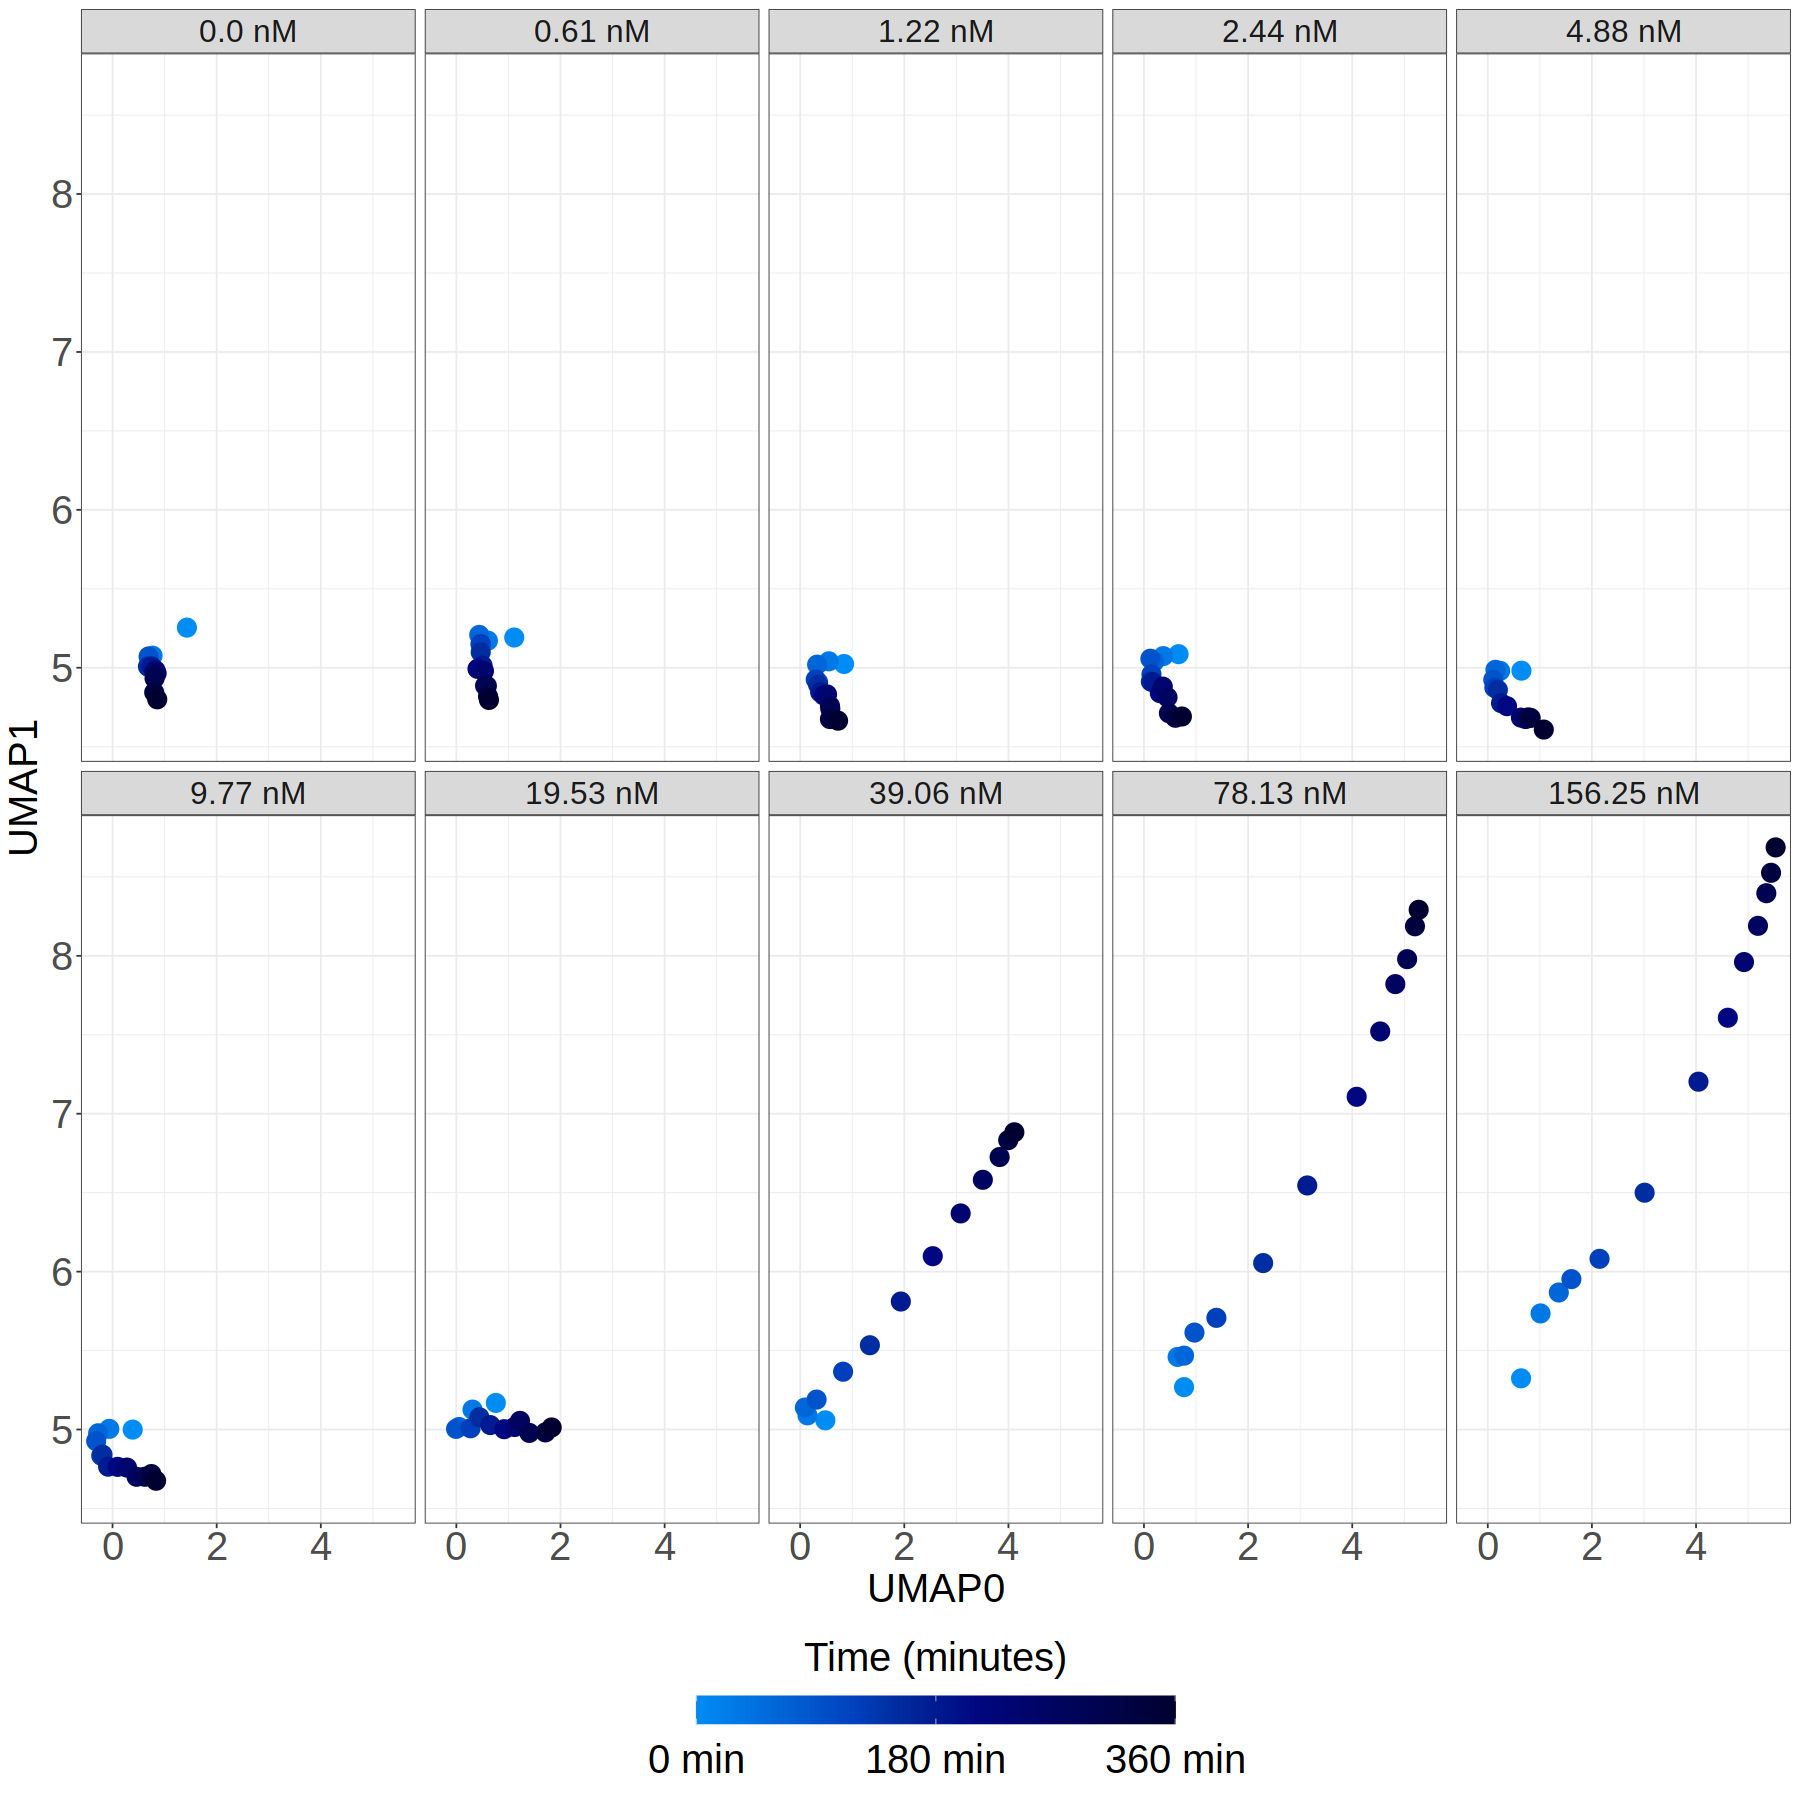

In [11]:

width <- 15
height <- 15
options(repr.plot.width = width, repr.plot.height = height)
# plot the centroids per dose over time
umap_centroid_plot <- (
    ggplot(data = umap_df_centroids, aes(x = UMAP0_centroid, y = UMAP1_centroid, color = Metadata_Time))
    + geom_point(size = 5)
    + theme_bw()
    + labs( x = "UMAP0", y = "UMAP1")
    # add custom colors
    + scale_color_gradientn(
        colors = temporal_palette,

        breaks = c(0, 180, 360), # breaks at 0, 90, and 360 minutes
        labels = c("0 min", "180 min", "360 min"),
        name = "Time (minutes)",
        guide = guide_colorbar(
            title.position = "top",
            title.hjust = 0.5,
            title.theme = element_text(size = 24),
            # make the legend longer 
            barwidth = 20
        )
    )
    + plot_themes
    + theme(strip.text = element_text(size = font_size - 5))
        
    + facet_wrap(~Metadata_dose_w_unit,nrow = 2)
    
)
umap_centroid_plot


In [12]:
# read in the 3d plot
map_3d_figure <- png::readPNG(map_3d_figure_path)
# rasterize
map_3d_figure <- grid::rasterGrob(map_3d_figure, interpolate = TRUE)


# Assemble all plots into a single figure

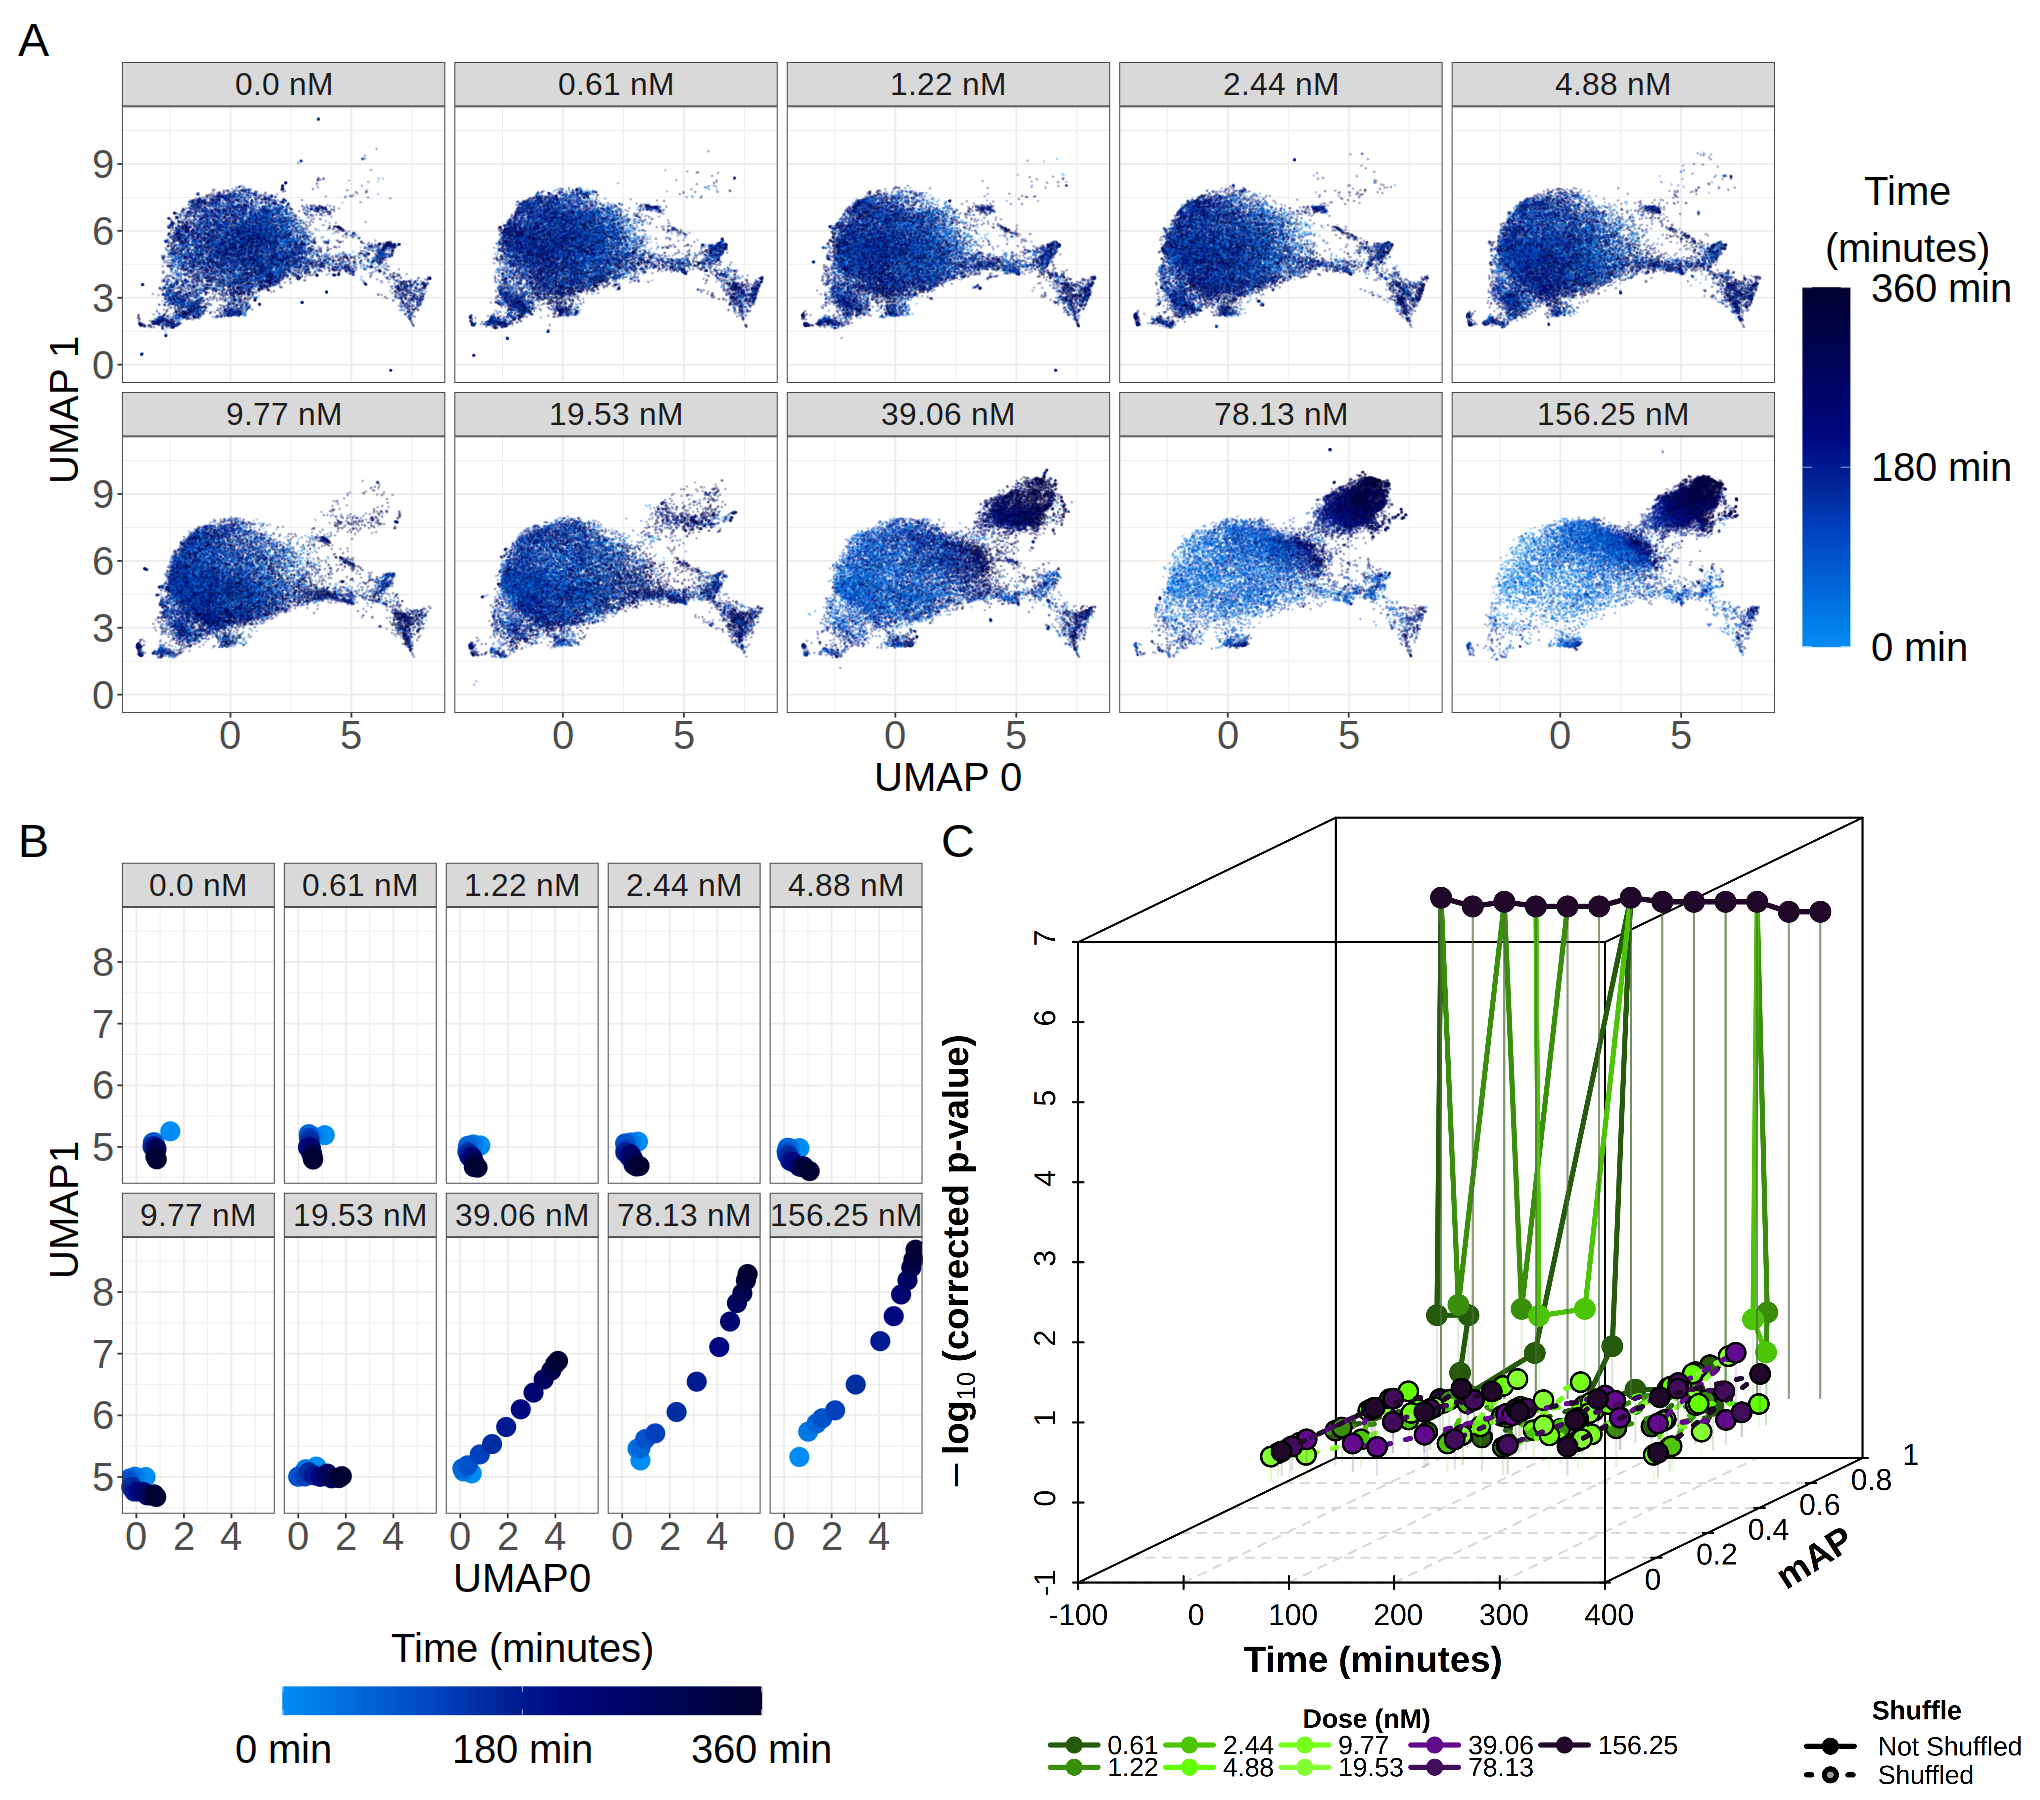

In [13]:
width <- 17
height <- 15
options(repr.plot.width=width, repr.plot.height=height)
layout <- "
AA
BC
"
metric_v_time_final_plot <- (
    umap_plot_facet
    + umap_centroid_plot
    + wrap_elements(full = map_3d_figure)

    + plot_layout(
        design = layout,
        widths = c(1, 1)
        )
    # make bottom plot not align
    + plot_annotation(tag_levels = 'A') & theme(plot.tag = element_text(size = 28))
)
ggsave(
    filename = final_figure_path,
    plot = metric_v_time_final_plot,
    width = width,
    height = height,
    dpi = 600
)
metric_v_time_final_plot